# Import

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from torch.utils.data import Dataset, DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter

# Dataset
from dataset_classes import AT

# Models
from models_with_temporal_graph import (
    TR_GNN_Attention,
    TR_GNN_GlobalLocal,
    TR_GNN_Linear,
    TR_GNN_MultiScale,
)


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Import Training and Testing Loops

In [ ]:
from helper_functions import train_model, test_model

In [5]:
import os
import json
import time
import math
import random
import traceback

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#from baseline metrics
BASELINE_VAL_LOSS = 0.0635180

# Sensitivity target model
SENSITIVITY_MODEL_CLS = TR_GNN_MultiScale

In [ ]:
# ============================================================
# SENSITIVITY — Dataset Preparation
# ============================================================

dataset = AT(
    csv_path=r"data/at/AT Dataset.csv",
    T_in=72,
    T_out=240,
    lag_hours=[1, 12, 24, 168],
    rolling_windows=[12, 24],
)

# ------------------------------------------------------------
# Raw split boundaries
# ------------------------------------------------------------
total_len = len(dataset.df_numeric)

train_split = int(0.6 * total_len)
val_split   = int(0.8 * total_len)

print(f"📊 Raw rows: {total_len}")
print(f"📊 Train split row: {train_split}")
print(f"📊 Val split row: {val_split}")

# ------------------------------------------------------------
# Fit scaler ONLY on training data
# ------------------------------------------------------------
scaler = StandardScaler()
scaler.fit(
    dataset.df_numeric.iloc[:train_split]
    .values.astype(np.float32)
)

# ------------------------------------------------------------
# Apply scaler to full dataset
# ------------------------------------------------------------
dataset.apply_scaler(scaler)
dataset.scaler = scaler

# ------------------------------------------------------------
# Effective sample ranges (with proper gap alignment)
# ------------------------------------------------------------
effective_len = len(dataset)

train_end  = min(train_split - dataset.T_in - dataset.T_out, effective_len)
val_start  = train_split - dataset.T_in          # gap-aligned val start
val_end    = min(val_split - dataset.T_in - dataset.T_out, effective_len)
test_start = val_split - dataset.T_in            # gap-aligned test start

train_idx = range(0, train_end)
val_idx   = range(val_start, val_end)
test_idx  = range(test_start, effective_len)

print(f"✅ Train samples: {len(train_idx)}")
print(f"✅ Val samples:   {len(val_idx)}")
print(f"✅ Test samples:  {len(test_idx)}")

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------
BATCH_SIZE = 32

train_loader = DataLoader(
    Subset(dataset, train_idx),
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    Subset(dataset, val_idx),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    Subset(dataset, test_idx),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Loaded dataset with 18 features (target=demand), total rows=52440
📊 Raw rows: 52440
📊 Train split row: 31464
📊 Val split row: 41952
✅ Train samples: 31152
✅ Val samples: 10488
✅ Test samples: 10488


In [11]:
RUN_NAME = "TR_GNN_AT_Multi_Scale"

# ── Save Directory ──────────────────────────────────────────
SAVE_DIR = "Sensitivity_Analysis_AT"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_DIR = os.path.join(SAVE_DIR, "best_models")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

FIG_DIR = os.path.join(SAVE_DIR, "loss_curves")
os.makedirs(FIG_DIR, exist_ok=True)

print(f"📁 Save dir: {SAVE_DIR}")

📁 Save dir: Sensitivity_Analysis_AT


In [ ]:
BASE_HPARAMS = dict(
    N=dataset.N,
    T_in=72,
    T_out=240,

    d=32,

    hidden_dim=64,       # BASE: 64
    GCN_Layer=5,         # BASE: 5

    dropout_forecast=0.1,
    dropout_gcn=0.2,
    dropout_temporal=0.2,

    kernel_size=7,       # BASE: 7
    dilation=3,          # BASE: 3

    lr=1e-3,
    scheduler_patience=3,
    weight_decay=1e-4,

    batch_size=BATCH_SIZE,
    epochs=100,

    lambda_smooth=0.01,
    lambda_sparse=1e-4,
)

# ------------------------------------------------------------
# Build experiments list (base + all sensitivity variants)
# ------------------------------------------------------------
experiments = []

# Base configuration
experiments.append(("Base", BASE_HPARAMS.copy()))

# 1. Kernel Size
for ks in [3, 5, 11]:
    cfg = BASE_HPARAMS.copy()
    cfg["kernel_size"] = ks
    experiments.append((f"Sens_KernelSize_{ks}", cfg))

# 2. Dilation
for d in [1, 2, 5]:
    cfg = BASE_HPARAMS.copy()
    cfg["dilation"] = d
    experiments.append((f"Sens_Dilation_{d}", cfg))

# 3. Hidden Dim
for hd in [32, 128, 256]:
    cfg = BASE_HPARAMS.copy()
    cfg["hidden_dim"] = hd
    experiments.append((f"Sens_HiddenDim_{hd}", cfg))

# 4. GCN Depth
for gl in [1, 2, 3, 7]:
    cfg = BASE_HPARAMS.copy()
    cfg["GCN_Layer"] = gl
    experiments.append((f"Sens_GCNDepth_{gl}", cfg))

print(f"🧪 Total experiments: {len(experiments)}")
print("✅ Base hyperparameters loaded.")

🧪 Loaded 13 sensitivity configs.
✅ Base hyperparameters loaded.


In [ ]:
class SensitivitySummaryWriter(SummaryWriter):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.train_losses = []
        self.val_losses = []

    def add_scalar(self, tag, scalar_value, global_step=None, *args, **kwargs):
        if tag == "Loss/train":
            self.train_losses.append(float(scalar_value))
        elif tag == "Loss/validation":
            self.val_losses.append(float(scalar_value))
        return super().add_scalar(tag, scalar_value, global_step, *args, **kwargs)


all_results = {}

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print(f"\n🚀 Total configurations to run: {len(experiments)}")

for run_idx, (cfg_name, hp) in enumerate(experiments, start=1):

    print("=" * 60)
    print(f"[{run_idx}/{len(experiments)}] Running: {cfg_name}")
    print(f"Config: Kernel={hp['kernel_size']}, Dilation={hp['dilation']}, "
          f"Hidden={hp['hidden_dim']}, GCN_Depth={hp['GCN_Layer']}")
    print("=" * 60)

    model = SENSITIVITY_MODEL_CLS(
        N=hp["N"],
        T_in=hp["T_in"],
        T_out=hp["T_out"],
        d=hp["d"],
        hidden_dim=hp["hidden_dim"],
        GCN_Layer=hp["GCN_Layer"],
        dropout_gcn=hp["dropout_gcn"],
        dropout_temporal=hp["dropout_temporal"],
        kernel_size=hp["kernel_size"],
        dilation=hp["dilation"],
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"🧠 Trainable params: {n_params:,}")

    run_tag  = f"{cfg_name}_GCN{hp['GCN_Layer']}_Hidden{hp['hidden_dim']}_Kernel{hp['kernel_size']}_Dil{hp['dilation']}"
    save_path = os.path.join(MODEL_SAVE_DIR, f"{cfg_name}_best_model.pth")

    log_dir = os.path.join("TR_GNN_AT_Sens", run_tag)
    writer  = SensitivitySummaryWriter(log_dir)
    writer.add_text("hparams", json.dumps(hp, indent=2))

    try:
        if device == "cuda":
            torch.cuda.reset_peak_memory_stats(device)
            torch.cuda.synchronize()

        train_start = time.perf_counter()
        model = train_model(
            model,
            train_loader,
            val_loader,
            epochs=hp["epochs"],
            lr=hp["lr"],
            device=device,
            scheduler_patience=hp["scheduler_patience"],
            writer=writer,
            weight_decay=hp["weight_decay"],
            save_path=save_path,
        )
        if device == "cuda":
            torch.cuda.synchronize()
        train_elapsed_s = time.perf_counter() - train_start
        epochs_run = max(len(writer.train_losses), 1)
        avg_epoch_time_s = train_elapsed_s / epochs_run

        print(f"\n🧪 Testing model performance for {cfg_name}...")
        if device == "cuda":
            torch.cuda.synchronize()
        inference_start = time.perf_counter()
        preds, trues = test_model(
            dataset=dataset,
            model=model,
            test_loader=test_loader,
            device=device,
            writer=writer,
        )
        if device == "cuda":
            torch.cuda.synchronize()
        inference_elapsed_s = time.perf_counter() - inference_start
        avg_inference_ms = (inference_elapsed_s / max(len(test_loader), 1)) * 1000
        peak_gpu_mem_mb = (
            torch.cuda.max_memory_allocated(device) / (1024 ** 2)
            if device == "cuda"
            else None
        )

        writer.close()

        # Collect metrics from test_model output
        preds_flat = preds.flatten()
        trues_flat = trues.flatten()

        test_mse = float(mean_squared_error(trues_flat, preds_flat))
        test_mae = float(mean_absolute_error(trues_flat, preds_flat))
        test_r2  = float(r2_score(trues_flat, preds_flat))

        best_val = min(writer.val_losses) if writer.val_losses else float("inf")

        beats = best_val < BASELINE_VAL_LOSS

        all_results[cfg_name] = dict(
            status="OK",
            GCN_Layer=hp["GCN_Layer"],
            hidden_dim=hp["hidden_dim"],
            kernel_size=hp["kernel_size"],
            dilation=hp["dilation"],
            n_params=n_params,
            best_val_loss=best_val,
            avg_epoch_time_s=avg_epoch_time_s,
            avg_inference_ms=avg_inference_ms,
            peak_gpu_mem_mb=peak_gpu_mem_mb,
            test_mse=test_mse,
            test_mae=test_mae,
            test_r2=test_r2,
            beats_baseline=beats,
            model_path=save_path,
            train_losses=writer.train_losses.copy(),
            val_losses=writer.val_losses.copy(),
        )

        flag = "✅ BEATS BASELINE" if beats else "❌ below baseline"
        mem_label = f"{peak_gpu_mem_mb:.0f}MB GPU" if peak_gpu_mem_mb is not None else "GPU n/a"
        print(
            f"\n→ Val {best_val:.4f} | MSE {test_mse:.4f} | MAE {test_mae:.4f} | "
            f"R² {test_r2:.4f} | {avg_epoch_time_s:.1f}s/epoch | "
            f"{avg_inference_ms:.1f}ms/batch | {mem_label} | {flag}"
        )

    except Exception as exc:
        writer.close()
        print(f"❌ FAILED: {exc}")
        traceback.print_exc()
        all_results[cfg_name] = dict(
            status="FAILED",
            error=str(exc),
            GCN_Layer=hp["GCN_Layer"],
            hidden_dim=hp["hidden_dim"],
            kernel_size=hp["kernel_size"],
            dilation=hp["dilation"],
        )

print("\n🏁 All sensitivity runs completed.")


[1/13] Running: gcn_depth_1
{'GCN_Layer': 1, 'hidden_dim': 64, 'kernel_size': 7, 'dilation': 3}
🧠 Trainable params: 752,672


Epoch 001 | Train 0.6238 | Val 0.2866 | Best 0.2866


Epoch 010 | Train 0.2377 | Val 0.0826 | Best 0.0826


Epoch 020 | Train 0.2203 | Val 0.0732 | Best 0.0732


Epoch 030 | Train 0.2141 | Val 0.0699 | Best 0.0699


...

Epoch 060 | Train 0.2011 | Val 0.0635 | Best 0.0635


Epoch 070 | Train 0.1979 | Val 0.0628 | Best 0.0627


Epoch 080 | Train 0.1927 | Val 0.0617 | Best 0.0616


Epoch 090 | Train 0.1911 | Val 0.0606 | Best 0.0606


Epoch 100 | Train 0.1910 | Val 0.0607 | Best 0.0606

→ Val 0.0606 | MSE 208860.5571 | 7.3s/epoch | 3.3ms/batch | 95MB GPU | ✅ BEATS BASELINE

🏁 All sensitivity runs completed.


In [18]:
# ============================================================
# SENSITIVITY — Summary DataFrame (SH)
# ============================================================

BASELINE_ROW = dict(

    config="baseline_estimated (GCN=5 | h=64 | k=7 | d=3)",

    GCN_Layer=5,
    hidden_dim=64,
    kernel_size=7,
    dilation=3,

    n_params=None,

    #from baseline metrics
    best_val_loss=0.0635180,

    #unknown
    avg_epoch_time_s=None,
    peak_gpu_mem_mb=None,
    avg_inference_ms=None,

    #from paper
    test_mse=0.1187,
    test_mae=0.2406,
    test_r2=0.8850,

    beats_baseline=False,

    model_path="Paper_Runs/TR_GNN_AT_Multi_Scale_best_model.pth",

    status="BASELINE_ESTIMATED",
)

rows = [BASELINE_ROW]

for cfg_name, r in all_results.items():

    base = dict(

        config=cfg_name,

        **{
            k: r.get(k)
            for k in [
                "GCN_Layer",
                "hidden_dim",
                "kernel_size",
                "dilation",

                "n_params",

                "best_val_loss",

                "avg_epoch_time_s",
                "peak_gpu_mem_mb",
                "avg_inference_ms",

                "test_mse",
                "test_mae",
                "test_r2",

                "beats_baseline",

                "model_path",

                "status",

                "train_losses",
                "val_losses",
            ]
        }
    )

    rows.append(base)

df_results = pd.DataFrame(rows)

print(
    df_results[
        [
            "config",
            "best_val_loss",
            "test_mse",
            "test_mae",
            "test_r2",
            "avg_epoch_time_s",
            "avg_inference_ms",
            "peak_gpu_mem_mb",
            "beats_baseline",
        ]
    ].to_string(index=False)
)

                                       config  best_val_loss      test_mse   test_mae  test_r2  avg_epoch_time_s  avg_inference_ms  peak_gpu_mem_mb  beats_baseline
baseline_estimated (GCN=5 | h=64 | k=7 | d=3)       0.063518      0.118700   0.240600 0.885000               NaN               NaN              NaN           False
                                  gcn_depth_1       0.061217 210985.466203 312.640171 0.909074          6.390948          2.780045        77.674805            True
                                  gcn_depth_2       0.060883 210606.038950 310.724447 0.909237          6.603520          2.900690        92.189941            True
                                  gcn_depth_3       0.060589 208425.993335 309.702599 0.910177          6.588308          3.021863        92.238281            True
                                  gcn_depth_7       0.062260 222483.307669 322.305526 0.904119          7.510444          3.444671        92.431641            True
                

In [19]:
# ============================================================
# SENSITIVITY — Excel Report Export
# ============================================================
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule

COLS = [
    ("Config", "config"), ("GCN Layers", "GCN_Layer"), ("Hidden Dim", "hidden_dim"),
    ("Kernel Size", "kernel_size"), ("Dilation", "dilation"), ("# Params", "n_params"),
    ("Best Val Loss", "best_val_loss"), ("Test MSE", "test_mse"), ("Test MAE", "test_mae"),
    ("Test R²", "test_r2"), ("Avg Epoch Time (s)", "avg_epoch_time_s"),
    ("Infer. ms/batch", "avg_inference_ms"), ("Peak GPU Mem (MB)", "peak_gpu_mem_mb"),
    ("Beats Baseline?", "beats_baseline"), ("Model Path", "model_path"), ("Status", "status"),
]

def _hdr(ws, row, col, value):
    c = ws.cell(row=row, column=col, value=value)
    c.font = Font(bold=True, color="FFFFFF", size=11)
    c.fill = PatternFill("solid", fgColor="1F4E79")
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c.border = Border(left=Side("thin","AAAAAA"), right=Side("thin","AAAAAA"),
                      top=Side("thin","AAAAAA"), bottom=Side("thin","AAAAAA"))
    return c

FILL_BASELINE = PatternFill("solid", fgColor="BDD7EE")
FILL_WIN      = PatternFill("solid", fgColor="C6EFCE")
FILL_FAIL     = PatternFill("solid", fgColor="FFC7CE")
FILL_NORM     = PatternFill("solid", fgColor="F9F9F9")

wb = openpyxl.Workbook()

# ── Sheet 1: Summary ──
ws1 = wb.active
ws1.title = "Sensitivity Results"
ws1.row_dimensions[1].height = 32
for col_i, (hdr, _) in enumerate(COLS, 1):
    _hdr(ws1, 1, col_i, hdr)

for row_i, row_data in enumerate(rows, 2):
    status = row_data.get("status", "")
    is_base = status == "BASELINE_ESTIMATED"
    is_fail = status == "FAILED"
    is_win  = row_data.get("beats_baseline", False)
    fill = FILL_BASELINE if is_base else FILL_WIN if is_win else FILL_FAIL if is_fail else FILL_NORM
    for col_i, (_, key) in enumerate(COLS, 1):
        val = row_data.get(key)
        c = ws1.cell(row=row_i, column=col_i, value=val)
        c.border = Border(left=Side("thin","AAAAAA"), right=Side("thin","AAAAAA"),
                          top=Side("thin","AAAAAA"), bottom=Side("thin","AAAAAA"))
        c.alignment = Alignment(horizontal="center", vertical="center")
        c.fill = fill
        if isinstance(val, float):
            c.number_format = "0.0000"

for col_i in range(1, len(COLS) + 1):
    max_w = max(len(str(ws1.cell(r, col_i).value or "")) for r in range(1, len(rows) + 2))
    ws1.column_dimensions[get_column_letter(col_i)].width = min(max_w + 3, 32)

val_col_letter = get_column_letter([k for _, k in COLS].index("best_val_loss") + 1)
ws1.conditional_formatting.add(
    f"{val_col_letter}2:{val_col_letter}{len(rows)+1}",
    ColorScaleRule(start_type="min", start_color="63BE7B", end_type="max", end_color="F8696B"),
)

ok_cfgs = {k: v for k, v in all_results.items() if v.get("status") == "OK"}

excel_path = os.path.join(SAVE_DIR, "sensitivity_analysis_results.xlsx")
wb.save(excel_path)
print(f"✅ Excel saved → {excel_path}")

✅ Excel saved → Sensitivity_Analysis_AT\sensitivity_analysis_results.xlsx


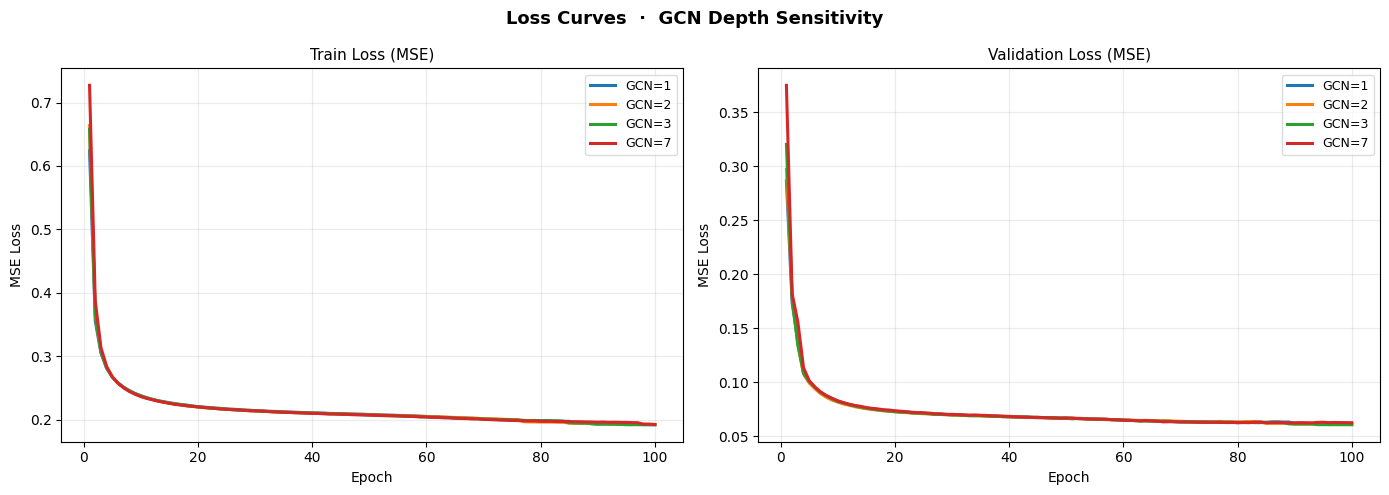

  📉 Saved: loss_curves_gcn_depth.png


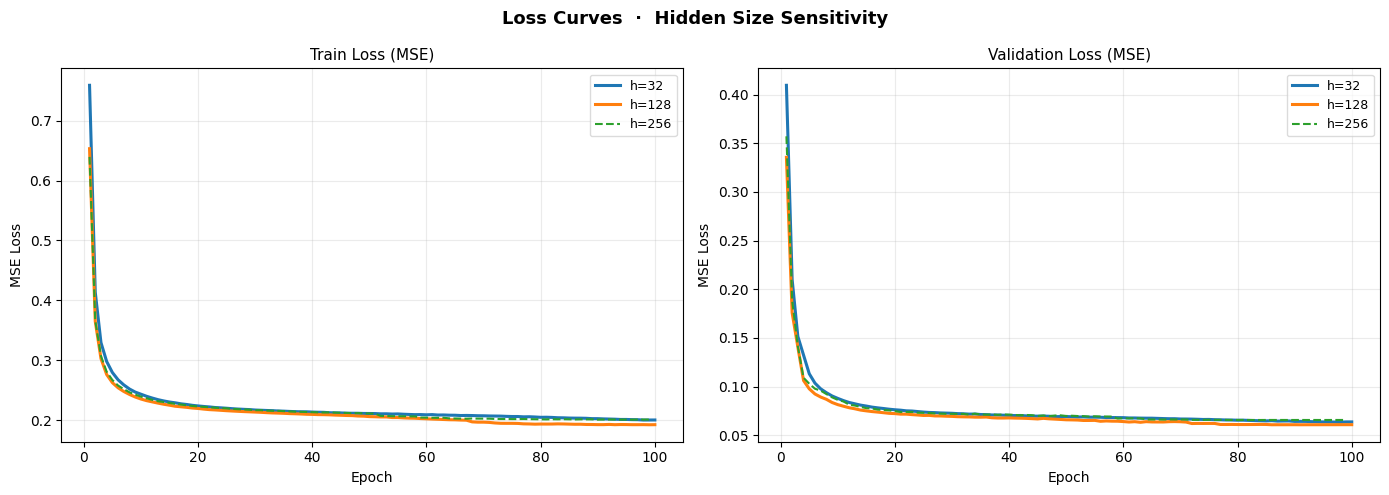

  📉 Saved: loss_curves_hidden_size.png


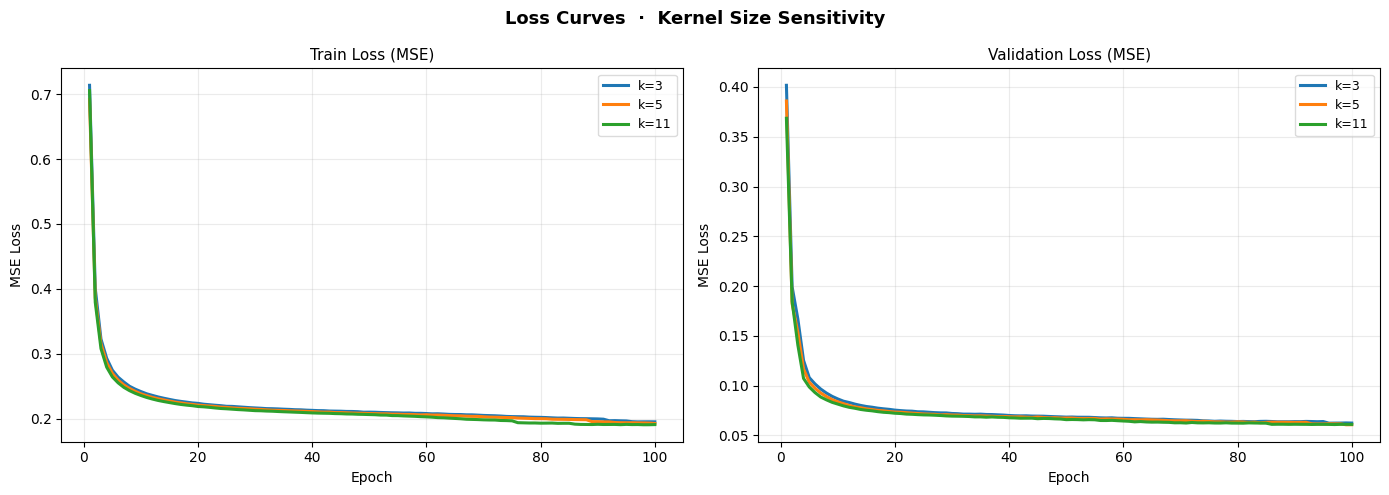

  📉 Saved: loss_curves_kernel_size.png


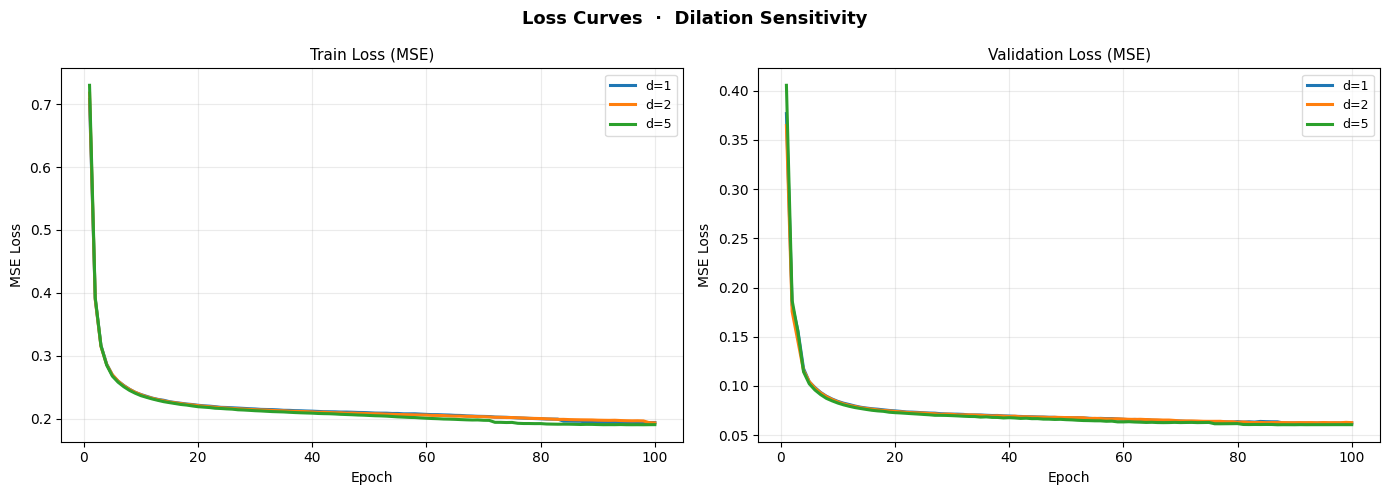

  📉 Saved: loss_curves_dilation.png


In [20]:
# ============================================================
# SENSITIVITY — Loss Curve Plots (one per sensitivity group)
# ============================================================
fig_dir = os.path.join(SAVE_DIR, "loss_curves")
os.makedirs(fig_dir, exist_ok=True)
GROUP_COLORS = plt.cm.tab10.colors

groups = {
    "GCN Depth":   {
        "Sens_GCNDepth_1": "GCN=1", "Sens_GCNDepth_2": "GCN=2",
        "Sens_GCNDepth_3": "GCN=3", "Sens_GCNDepth_7": "GCN=7",
    },
    "Hidden Size": {
        "Sens_HiddenDim_32": "h=32", "Sens_HiddenDim_128": "h=128",
        "Sens_HiddenDim_256": "h=256",
    },
    "Kernel Size": {
        "Sens_KernelSize_3": "k=3", "Sens_KernelSize_5": "k=5",
        "Sens_KernelSize_11": "k=11",
    },
    "Dilation":    {
        "Sens_Dilation_1": "d=1", "Sens_Dilation_2": "d=2",
        "Sens_Dilation_5": "d=5",
    },
}

for group_name, cfg_label_map in groups.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(f"Loss Curves  ·  {group_name} Sensitivity", fontsize=13, fontweight="bold")

    for ax, loss_key, panel_title in zip(axes, ["train_losses", "val_losses"],
                                         ["Train Loss (MSE)", "Validation Loss (MSE)"]):
        for ci, (cfg_name, label) in enumerate(cfg_label_map.items()):
            r = ok_cfgs.get(cfg_name)
            if r is None: continue
            curve = r.get(loss_key, [])
            lw = 2.2 if r.get("beats_baseline") else 1.5
            ls = "-" if r.get("beats_baseline") else "--"
            ax.plot(range(1, len(curve)+1), curve,
                    color=GROUP_COLORS[ci % len(GROUP_COLORS)],
                    linewidth=lw, linestyle=ls, label=label)

        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel("MSE Loss", fontsize=10)
        ax.set_title(panel_title, fontsize=11)
        ax.set_yscale("linear")
        ax.legend(fontsize=9, framealpha=0.7)
        ax.grid(True, which="both", alpha=0.25)

    plt.tight_layout()
    fname = f"loss_curves_{group_name.replace(' ','_').lower()}.png"
    fig.savefig(os.path.join(fig_dir, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  📉 Saved: {fname}")

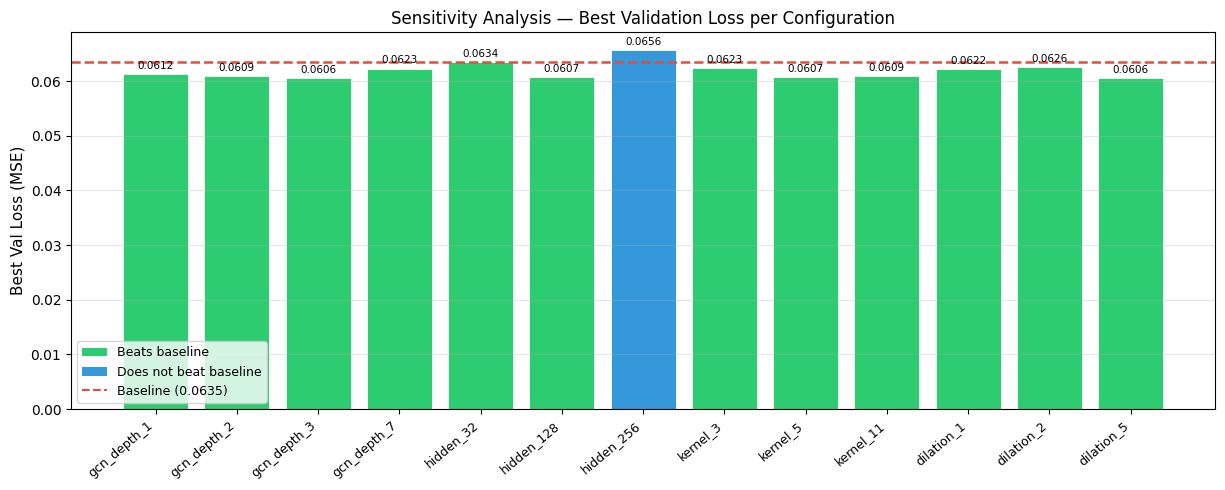

  📊 Saved: summary_val_loss_bar.png


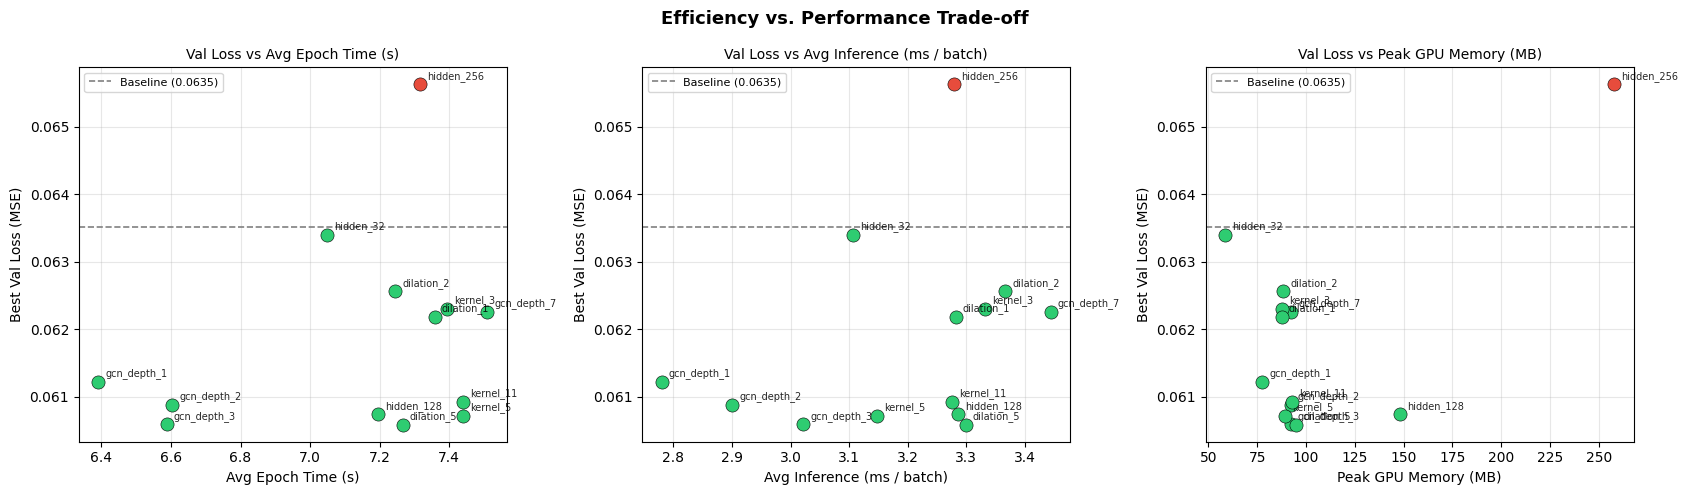

  📈 Saved: efficiency_scatter.png

✅ All outputs written to:  Sensitivity_Analysis_AT/
   📊  Excel  : sensitivity_analysis_results.xlsx
   📈  Figures: loss_curves/  (6 PNGs)

🏆 12 config(s) beat the baseline — models saved for XAI reuse:
   • gcn_depth_1          | Val 0.0612 | Sensitivity_Analysis_AT\best_models\gcn_depth_1_best_model.pth
   • gcn_depth_2          | Val 0.0609 | Sensitivity_Analysis_AT\best_models\gcn_depth_2_best_model.pth
   • gcn_depth_3          | Val 0.0606 | Sensitivity_Analysis_AT\best_models\gcn_depth_3_best_model.pth
   • gcn_depth_7          | Val 0.0623 | Sensitivity_Analysis_AT\best_models\gcn_depth_7_best_model.pth
   • hidden_32            | Val 0.0634 | Sensitivity_Analysis_AT\best_models\hidden_32_best_model.pth
   • hidden_128           | Val 0.0607 | Sensitivity_Analysis_AT\best_models\hidden_128_best_model.pth
   • kernel_3             | Val 0.0623 | Sensitivity_Analysis_AT\best_models\kernel_3_best_model.pth
   • kernel_5             | Val 0.0607 |

In [23]:
# ============================================================
# SENSITIVITY — Bar Plot, Scatter Plots & Final Summary
# ============================================================
ok_items = [(k, v) for k, v in all_results.items() if v.get("status") == "OK"]

# ── 1. Summary Bar: Best Val Loss ──
if ok_items:
    names      = [k for k, _ in ok_items]
    val_losses = [v["best_val_loss"] for _, v in ok_items]
    bar_colors = ["#2ecc71" if v["beats_baseline"] else "#3498db" for _, v in ok_items]

    fig, ax = plt.subplots(figsize=(max(12, len(names) * 0.95), 5))
    bars = ax.bar(names, val_losses, color=bar_colors, edgecolor="white", linewidth=0.6)
    if BASELINE_VAL_LOSS < float("inf"):
        ax.axhline(BASELINE_VAL_LOSS, color="#e74c3c", linestyle="--",
                   linewidth=1.8, label=f"Baseline ({BASELINE_VAL_LOSS:.4f})")
    ax.set_ylabel("Best Val Loss (MSE)", fontsize=11)
    ax.set_title("Sensitivity Analysis — Best Validation Loss per Configuration", fontsize=12)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    for bar, loss in zip(bars, val_losses):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{loss:.4f}", ha="center", va="bottom", fontsize=7.5)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor="#2ecc71", label="Beats baseline"),
        Patch(facecolor="#3498db", label="Does not beat baseline"),
        plt.Line2D([0],[0], color="#e74c3c", linestyle="--", label=f"Baseline ({BASELINE_VAL_LOSS:.4f})"),
    ], fontsize=9)

    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "summary_val_loss_bar.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  📊 Saved: summary_val_loss_bar.png")

# ── 2. Efficiency Scatter: Val Loss vs Time/Mem ──
if ok_items:
    metrics_to_plot = [
        ("avg_epoch_time_s", "Avg Epoch Time (s)"),
        ("avg_inference_ms", "Avg Inference (ms / batch)"),
        ("peak_gpu_mem_mb",  "Peak GPU Memory (MB)"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Efficiency vs. Performance Trade-off", fontsize=13, fontweight="bold")

    for ax, (metric_key, xlabel) in zip(axes, metrics_to_plot):
        for cfg_name, r in ok_items:
            x = r.get(metric_key)
            y = r.get("best_val_loss")
            if x is None or y is None: continue
            color = "#2ecc71" if r["beats_baseline"] else "#e74c3c"
            ax.scatter(x, y, color=color, s=90, zorder=3, edgecolors="black", linewidth=0.4)
            ax.annotate(cfg_name, (x, y), textcoords="offset points",
                        xytext=(5, 4), fontsize=7, alpha=0.85)

        if BASELINE_VAL_LOSS < float("inf"):
            ax.axhline(BASELINE_VAL_LOSS, color="gray", linestyle="--",
                       linewidth=1.2, label=f"Baseline ({BASELINE_VAL_LOSS:.4f})")
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Best Val Loss (MSE)", fontsize=10)
        ax.set_title(f"Val Loss vs {xlabel}", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "efficiency_scatter.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  📈 Saved: efficiency_scatter.png")

# ── 3. Final Console Summary ──
print(f"\n{'='*64}")
print(f"✅ All outputs written to:  {SAVE_DIR}/")
print(f"   📊  Excel  : sensitivity_analysis_results.xlsx")
print(f"   📈  Figures: loss_curves/  ({4 + 2} PNGs)")
print(f"{'='*64}")

winners = [(k, v) for k, v in all_results.items() if v.get("beats_baseline")]
if winners:
    print(f"\n🏆 {len(winners)} config(s) beat the baseline — models saved for XAI reuse:")
    for k, v in winners:
        print(f"   • {k:20s} | Val {v['best_val_loss']:.4f} | {v['model_path']}")
else:
    print("\n  No config beat the baseline this run.")